# Lab 6: Traversing Graphs — Euler and Hamilton

In this lab, you will study two different traversal problems.

An **Euler trail** uses every edge exactly once.

A **Hamilton path** visits every vertex exactly once.

At first, these may sound similar. But as you experiment, you will see that they behave very differently.

Your goals are to:
- explore which graphs admit Euler trails or Euler circuits,
- compare these with Hamilton paths and Hamilton cycles,
- investigate the role of vertex degree,
- test how small changes in a graph affect traversal behavior,
- decide which patterns seem to be governed by a theorem and which seem harder to predict.

In [1]:
from lab6_helpers import *

### Part 1: Eulerian graphs

In [2]:
# Start by building some baseline graphs

def sample_cycle_graph_edges():
    # Euler circuit, also Hamilton cycle
    return [("A", "B"), ("B", "C"), ("C", "D"), ("D", "A")]


def sample_path_graph_edges():
    # Euler trail, not Euler circuit
    return [("A", "B"), ("B", "C"), ("C", "D")]


def sample_non_eulerian_edges():
    # More than two odd-degree vertices
    return [
        ("A", "B"),
        ("A", "C"),
        ("A", "D"),
        ("B", "C"),
        ("C", "D"),
    ]


def sample_hamilton_but_not_euler_edges():
    # Small example that can have Hamilton cycle but not Euler circuit
    return [
        ("A", "B"),
        ("B", "C"),
        ("C", "D"),
        ("D", "A"),
        ("A", "C"),
    ]


def sample_euler_but_not_hamilton_edges():
    # Figure-eight style graph
    return [
        ("A", "B"),
        ("B", "C"),
        ("C", "A"),
        ("C", "D"),
        ("D", "E"),
        ("E", "C"),
    ]

Before asking whether a graph has an Euler trail or Euler circuit, inspect its degrees.

What do you notice about the odd-degree vertices?

In [3]:
G1 = build_graph(sample_cycle_graph_edges())
graph_summary(G1)

{'number_of_nodes': 4,
 'number_of_edges': 4,
 'connected': True,
 'degree_table': [('A', 2), ('B', 2), ('C', 2), ('D', 2)],
 'odd_degree_vertices': [],
 'num_odd_degree_vertices': 0}

In [4]:
et = has_euler_trail(G1)
ec = has_euler_circuit(G1)
print(f"Euler trail? {et}, Euler circuit? {ec}")

Euler trail? True, Euler circuit? True


In [5]:
get_euler_circuit(G1)

[('A', 'D'), ('D', 'C'), ('C', 'B'), ('B', 'A')]

And what about a graph with exactly two odd-degree vertices?

In [6]:
G2 = build_graph(sample_path_graph_edges())
graph_summary(G2)

{'number_of_nodes': 4,
 'number_of_edges': 3,
 'connected': True,
 'degree_table': [('B', 2), ('C', 2), ('A', 1), ('D', 1)],
 'odd_degree_vertices': ['A', 'D'],
 'num_odd_degree_vertices': 2}

In [7]:
et = has_euler_trail(G2)
ec = has_euler_circuit(G2)
print(f"Euler trail? {et}, Euler circuit? {ec}")

Euler trail? True, Euler circuit? False


And a graph that is not Eulerian.

In [9]:
G3 = build_graph(sample_non_eulerian_edges())
graph_summary(G3)

{'number_of_nodes': 4,
 'number_of_edges': 5,
 'connected': True,
 'degree_table': [('A', 3), ('C', 3), ('B', 2), ('D', 2)],
 'odd_degree_vertices': ['A', 'C'],
 'num_odd_degree_vertices': 2}

In [10]:
et = has_euler_trail(G3)
ec = has_euler_circuit(G3)
print(f"Euler trail? {et}, Euler circuit? {ec}")

Euler trail? True, Euler circuit? False


### Part 2: Euler trails and Euler circuits

What do odd-degree vertices seem to control?

Compare your examples.

Questions:
- When does an Euler circuit appear?
- When does an Euler trail but not a circuit appear?
- What role do odd-degree vertices seem to play?
- Can you state a conjecture relating odd-degree vertices to Euler trails?

### Part 3: Hamilton paths and cycles

Now switch from “use every edge once” to “visit every vertex once.”
These are not the same problem.

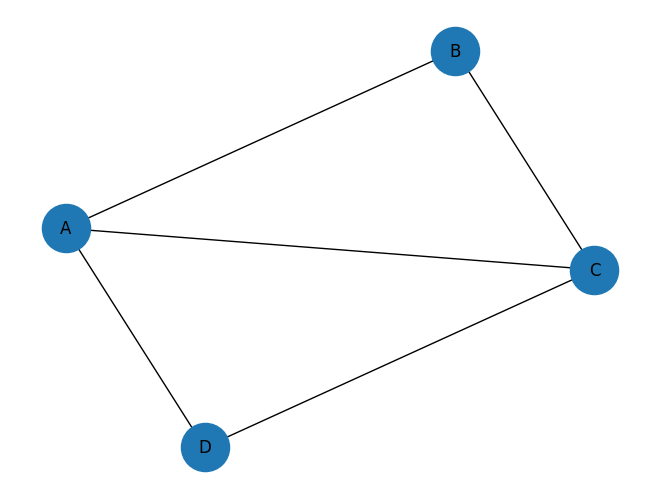

{'number_of_nodes': 4,
 'number_of_edges': 5,
 'connected': True,
 'degree_table': [('A', 3), ('C', 3), ('B', 2), ('D', 2)],
 'odd_degree_vertices': ['A', 'C'],
 'num_odd_degree_vertices': 2}

In [11]:
H1 = build_graph(sample_hamilton_but_not_euler_edges())
draw_graph(H1)
graph_summary(H1)

Finding Hamiltonian paths is a bit more complex than in the Eulerian case. To assist with the computation, we'll take a brute-force approach, meaning we will basically try and check all the possibilities. This is inefficient in general, but good enough for the small graphs we are working with right now.

In [12]:
find_hamilton_path_bruteforce(H1)

['A', 'B', 'C', 'D']

In [16]:
find_hamilton_cycle_bruteforce(H1)

['A', 'B', 'C', 'D']

In [13]:
has_euler_trail(H1), has_euler_circuit(H1)

(True, False)

Now compare to another graph, having a 'figure-8' like structure.

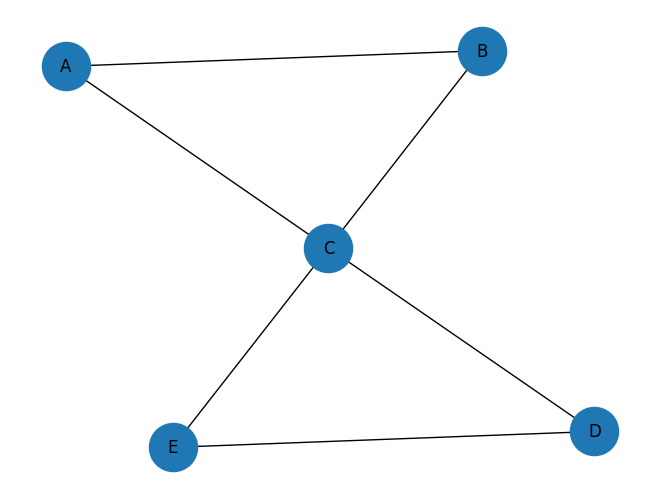

{'number_of_nodes': 5,
 'number_of_edges': 6,
 'connected': True,
 'degree_table': [('C', 4), ('A', 2), ('B', 2), ('D', 2), ('E', 2)],
 'odd_degree_vertices': [],
 'num_odd_degree_vertices': 0}

In [14]:
H2 = build_graph(sample_euler_but_not_hamilton_edges())
draw_graph(H2)
graph_summary(H2)

In [15]:
find_hamilton_path_bruteforce(H2)

['A', 'B', 'C', 'D', 'E']

In [17]:
find_hamilton_cycle_bruteforce(H2)

### Part 4: Euler versus Hamilton

At this point, compare what the two problems are asking.

Questions:
- Which problem seems easier to predict from local data such as degree?
- Which one seems more global and harder to guess?
- Can a graph be Eulerian but not Hamiltonian?
- Can a graph be Hamiltonian but not Eulerian?

I encourage you to develop some more graphs and compare these two definitions, as well as explore the limits of the brute force approach we took in the Hamiltonian case. Play around, see if you can find anything cool, explore some of the other functionality provided in the helpers file, and break things!